In [1]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/movie-recommender/venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm.notebook import tqdm
import warnings, joblib, os

warnings.filterwarnings("ignore")
%matplotlib inline
print("✅ Imports done")

✅ Imports done


In [3]:
#config

DATA_DIR      = "../data/raw/"
PROCESSED_DIR = "../data/processed/"
MODEL_DIR     = "../models/"
FIGURES_DIR   = "../reports/figures/"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,     exist_ok=True)
os.makedirs(FIGURES_DIR,   exist_ok=True)

MIN_USER_RATINGS  = 20
MIN_MOVIE_RATINGS = 20
RANDOM_STATE      = 42

print("✅ Config set")

✅ Config set


In [6]:
#load and filter ratings
ratings = pd.read_csv(DATA_DIR + "ratings.csv")
movies  = pd.read_csv(DATA_DIR + "movies.csv")

print(f"Raw: {len(ratings):,} ratings")

movie_counts = ratings.groupby("movieId")["rating"].count()
user_counts  = ratings.groupby("userId")["rating"].count()

ratings = ratings[
    ratings["movieId"].isin(movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index) &
    ratings["userId"].isin(user_counts[user_counts   >= MIN_USER_RATINGS].index)
].reset_index(drop=True)

print(f"Filtered: {len(ratings):,} ratings")
print(f"Users: {ratings['userId'].nunique():,} | Movies: {ratings['movieId'].nunique():,}")

Raw: 25,000,095 ratings
Filtered: 24,810,483 ratings
Users: 162,541 | Movies: 18,430


In [7]:
# temporal Train-Test split

ratings = ratings.sort_values(["userId", "timestamp"])
ratings["rank_pct"] = ratings.groupby("userId")["timestamp"].rank(
    method="first", ascending=True, pct=True
)

train = ratings[ratings["rank_pct"] <= 0.8].drop(columns=["rank_pct"]).reset_index(drop=True)
test  = ratings[ratings["rank_pct"] >  0.8].drop(columns=["rank_pct"]).reset_index(drop=True)

print(f"Train: {len(train):,} | Test: {len(test):,}")

# Save for all later notebooks
train.to_parquet(PROCESSED_DIR + "train.parquet", index=False)
test.to_parquet(PROCESSED_DIR  + "test.parquet",  index=False)
print("✅ Saved train/test to data/processed/")

Train: 19,784,257 | Test: 5,026,226
✅ Saved train/test to data/processed/


In [8]:
# Build User-Item matrix for train set

SAMPLE_USERS = 5000   # ↑ increase for better coverage, ↓ for faster iteration

sample_users = train["userId"].drop_duplicates().sample(SAMPLE_USERS, random_state=RANDOM_STATE)
train_s      = train[train["userId"].isin(sample_users)]
test_s       = test[test["userId"].isin(sample_users)]

user2idx  = {u: i for i, u in enumerate(train_s["userId"].unique())}
movie2idx = {m: i for i, m in enumerate(train_s["movieId"].unique())}
idx2movie = {v: k for k, v in movie2idx.items()}

user_item_matrix = csr_matrix(
    (train_s["rating"].values,
     (train_s["userId"].map(user2idx), train_s["movieId"].map(movie2idx))),
    shape=(len(user2idx), len(movie2idx))
)

print(f"Matrix: {user_item_matrix.shape} | Non-zero: {user_item_matrix.nnz:,}")

Matrix: (5000, 14629) | Non-zero: 622,708


In [9]:
# Compute user similarity

print("Computing cosine similarity (may take ~30s)...")
user_sim    = cosine_similarity(user_item_matrix, dense_output=False)
GLOBAL_MEAN = train_s["rating"].mean()
K           = 50

print(f"Similarity matrix: {user_sim.shape}")
print("✅ Done")

Computing cosine similarity (may take ~30s)...
Similarity matrix: (5000, 5000)
✅ Done


In [10]:
#Predict Function

def predict_rating(user_id, movie_id):
    if user_id not in user2idx or movie_id not in movie2idx:
        return GLOBAL_MEAN

    u_idx    = user2idx[user_id]
    m_idx    = movie2idx[movie_id]
    col      = user_item_matrix[:, m_idx].toarray().flatten()
    rated_by = np.where(col > 0)[0]

    if len(rated_by) == 0:
        return GLOBAL_MEAN

    sims = np.array(user_sim[u_idx, rated_by].todense()).flatten()
    rats = col[rated_by]
    mask = sims > 0
    sims, rats = sims[mask], rats[mask]

    if len(sims) == 0:
        return GLOBAL_MEAN

    top  = np.argsort(sims)[-min(K, len(sims)):]
    w, r = sims[top], rats[top]
    return float(np.dot(w, r) / w.sum()) if w.sum() > 0 else GLOBAL_MEAN

print("✅ Prediction function defined")

✅ Prediction function defined


In [11]:
# Generate prediction

test_eval = test_s[
    test_s["userId"].isin(user2idx) &
    test_s["movieId"].isin(movie2idx)
].copy()

print(f"Evaluating on {len(test_eval):,} test ratings...")

preds_baseline = np.clip([
    predict_rating(r.userId, r.movieId)
    for r in tqdm(test_eval.itertuples(), total=len(test_eval))
], 0.5, 5.0)

Evaluating on 155,876 test ratings...


  0%|          | 0/155876 [00:00<?, ?it/s]

In [12]:
# Evaluate

y_true     = test_eval["rating"].values
rmse_base  = np.sqrt(mean_squared_error(y_true, preds_baseline))
mae_base   = mean_absolute_error(y_true, preds_baseline)

print("=" * 40)
print("📊 Baseline — User-Based CF")
print(f"   RMSE : {rmse_base:.4f}")
print(f"   MAE  : {mae_base:.4f}")
print("=" * 40)

baseline_results = {"model": "UserCF", "RMSE": rmse_base, "MAE": mae_base}

📊 Baseline — User-Based CF
   RMSE : 0.9629
   MAE  : 0.7443


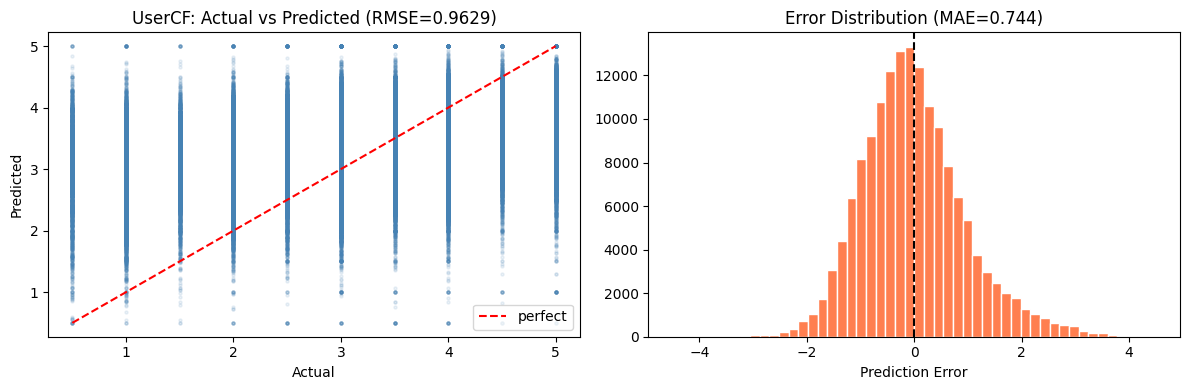

In [13]:
# Visualize predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_true, preds_baseline, alpha=0.1, s=5, color="steelblue")
axes[0].plot([0.5, 5], [0.5, 5], "r--", label="perfect")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"UserCF: Actual vs Predicted (RMSE={rmse_base:.4f})")
axes[0].legend()

errors = preds_baseline - y_true
axes[1].hist(errors, bins=50, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", ls="--")
axes[1].set_title(f"Error Distribution (MAE={mae_base:.3f})")
axes[1].set_xlabel("Prediction Error")

plt.tight_layout()
plt.savefig(FIGURES_DIR + "baseline_eval.png", dpi=150)
plt.show()

In [14]:
# Sample Reccomendations

def recommend_movies(user_id, n=10):
    if user_id not in user2idx:
        print("User not in training set")
        return
    u_idx  = user2idx[user_id]
    scores = user_item_matrix.T.dot(user_sim[u_idx].T).toarray().flatten()
    seen   = user_item_matrix[u_idx].nonzero()[1]
    scores[seen] = -np.inf
    top    = [idx2movie[i] for i in np.argsort(scores)[-n:][::-1]]
    print(f"\n🎬 Top {n} for User {user_id}:")
    print(movies[movies["movieId"].isin(top)][["movieId", "title"]].to_string(index=False))

recommend_movies(test_eval["userId"].iloc[0])


🎬 Top 10 for User 13:
 movieId                                  title
      50             Usual Suspects, The (1995)
     457                   Fugitive, The (1993)
     527                Schindler's List (1993)
     588                         Aladdin (1992)
     608                           Fargo (1996)
     858                  Godfather, The (1972)
    1036                        Die Hard (1988)
    1136 Monty Python and the Holy Grail (1975)
    1197             Princess Bride, The (1987)
   79132                       Inception (2010)


In [ ]:
#save

joblib.dump({
    "results": baseline_results,
    "preds": preds_baseline,
    "test_index": test_eval.index.tolist()
}, MODEL_DIR + "baseline_cf.joblib")

print("✅ Baseline saved — move to 03_svd.ipynb")

✅ Baseline saved — move to 03_svd.ipynb


: 